# CareerMatch AI

## Project Overview

CareerMatch AI is an intelligent career guidance and job recommendation system designed to help users navigate the job market more effectively. The solution leverages Artificial Intelligence, job market data, and semantic search technologies to connect users with relevant employment opportunities while providing insights into required skills, qualifications, and career pathways.

The project uses a LinkedIn Job Postings dataset containing information about job titles, companies, descriptions, compensation, work arrangements, locations, application details, and skill requirements. By combining structured data with Large Language Models (LLMs), the system aims to provide personalized recommendations, answer career-related questions, and help users make informed professional decisions.

## Business Problem

Searching for jobs can be a time-consuming and overwhelming process. Job seekers often struggle to identify positions that align with their skills, experience, and career goals while also understanding what qualifications are needed for specific roles.

CareerMatch AI addresses this challenge by creating an AI-powered assistant capable of retrieving relevant job opportunities, analyzing job requirements, identifying skill gaps, and providing career recommendations based on user needs.

## Project Goals

The primary goals of this project are to:

- Build an AI-powered career recommendation agent.
- Prepare and organize job posting data for AI-driven applications.
- Enable intelligent search and retrieval across job listings.
- Support skill matching and career guidance workflows.
- Provide personalized and explainable job recommendations.
- Evaluate the effectiveness of different LLMs within the agent workflow.
- Demonstrate both the technical and business value of an AI-powered career assistant.


# 1. Setup Unity Catalog

This section creates the Unity Catalog environment used throughout the project. The catalog and schema provide a centralized location for storing cleaned datasets, agent-ready tables, and other project assets.

In [0]:
# Create and configure the Unity Catalog environment

catalog = "finalproject"
schema = "careermatch_ai"

# Create project schema if it does not already exist
spark.sql(f"CREATE SCHEMA IF NOT EXISTS {catalog}.{schema}")

# Set active catalog and schema
spark.sql(f"USE CATALOG {catalog}")
spark.sql(f"USE SCHEMA {schema}")

# Verify environment
print(f"Using Unity Catalog location: {catalog}.{schema}")

spark.sql("SELECT current_catalog(), current_schema()").show()

Using Unity Catalog location: finalproject.careermatch_ai
+-----------------+----------------+
|current_catalog()|current_schema()|
+-----------------+----------------+
|     finalproject|  careermatch_ai|
+-----------------+----------------+



# 2. Load the Raw LinkedIn Job Postings Dataset 
The dataset contains job posting information such as job title, company, location, salary, work type, application type, job description, and skills.

This raw dataset will be cleaned and converted into agent-ready tables.

In [0]:
# Load LinkedIn job postings dataset from Unity Catalog Volume

file_path = "/Volumes/finalproject/careermatch_ai/raw_data/postings.csv"

jobs_raw = (
    spark.read
    .option("header", True)
    .option("inferSchema", True)
    .option("multiLine", True)
    .option("escape", '"')
    .csv(file_path)
)

print("Raw row count:", jobs_raw.count())
print("Raw column count:", len(jobs_raw.columns))

jobs_raw.printSchema()
display(jobs_raw.limit(5))

Raw row count: 123849
Raw column count: 31
root
 |-- job_id: long (nullable = true)
 |-- company_name: string (nullable = true)
 |-- title: string (nullable = true)
 |-- description: string (nullable = true)
 |-- max_salary: double (nullable = true)
 |-- pay_period: string (nullable = true)
 |-- location: string (nullable = true)
 |-- company_id: double (nullable = true)
 |-- views: double (nullable = true)
 |-- med_salary: double (nullable = true)
 |-- min_salary: double (nullable = true)
 |-- formatted_work_type: string (nullable = true)
 |-- applies: double (nullable = true)
 |-- original_listed_time: double (nullable = true)
 |-- remote_allowed: double (nullable = true)
 |-- job_posting_url: string (nullable = true)
 |-- application_url: string (nullable = true)
 |-- application_type: string (nullable = true)
 |-- expiry: double (nullable = true)
 |-- closed_time: double (nullable = true)
 |-- formatted_experience_level: string (nullable = true)
 |-- skills_desc: string (nullable =

job_id,company_name,title,description,max_salary,pay_period,location,company_id,views,med_salary,min_salary,formatted_work_type,applies,original_listed_time,remote_allowed,job_posting_url,application_url,application_type,expiry,closed_time,formatted_experience_level,skills_desc,listed_time,posting_domain,sponsored,work_type,currency,compensation_type,normalized_salary,zip_code,fips
921716,Corcoran Sawyer Smith,Marketing Coordinator,"Job descriptionA leading real estate firm in New Jersey is seeking an administrative Marketing Coordinator with some experience in graphic design. You will be working closely with our fun, kind, ambitious members of the sales team and our dynamic executive team on a daily basis. This is an opportunity to be part of a fast-growing, highly respected real estate brokerage with a reputation for exceptional marketing and extraordinary culture of cooperation and inclusion.Who you are:You must be a well-organized, creative, proactive, positive, and most importantly, kind-hearted person. Please, be responsible, respectful, and cool-under-pressure. Please, be proficient in Adobe Creative Cloud (Indesign, Illustrator, Photoshop) and Microsoft Office Suite. Above all, have fantastic taste and be a good-hearted, fun-loving person who loves working with people and is eager to learn.Role:Our office is a fast-paced environment. You’ll work directly with a Marketing team and communicate daily with other core staff and our large team of agents. This description is a brief overview, but your skills and interests will be considered in what you work on and as the role evolves over time.Agent Assistance- Receive & Organize Marketing Requests from Agents- Track Tasks & Communicate with Marketing team & Agents on Status- Prepare print materials and signs for open houses- Submit Orders to Printers & Communicate & Track DeadlinesGraphic Design & Branding- Managing brand strategy and messaging through website, social media, videos, online advertising, print placement and events- Receive, organize, and prioritize marketing requests from agents- Fulfill agent design requests including postcards, signs, email marketing and property brochures using pre-existing templates and creating custom designs- Maintain brand assets and generic filesEvents & Community- Plan and execute events and promotions- Manage Contacts & Vendors for Event Planning & SponsorshipsOur company is committed to creating a diverse environment and is proud to be an equal opportunity employer. All qualified applicants will receive consideration for employment without regard to race, color, religion, gender, gender identity or expression, sexual orientation, national origin, genetics, disability, age, or veteran status.Job Type: Full-time Pay: $18-20/hour Expected hours: 35 – 45 per week Benefits:Paid time offSchedule:8 hour shiftMonday to FridayExperience:Marketing: 1 year (Preferred)Graphic design: 2 years (Preferred)Work Location: In person",20.0,HOURLY,"Princeton, NJ",2774458.0,20.0,null,17.0,Full-time,2.0,1.713397508E12,null,https://www.linkedin.com/jobs/view/921716/?trk=jobs_biz_prem_srch,null,ComplexOnsiteApply,1.715989508E12,null,null,"Requirements: We are seeking a College or Graduate Student (can also be completed with school) with a focus in Planning, Architecture, Real Estate Development or Management or General Business. Must be able to work in an extremely fast paced environment and able to multitask and prioritize.",1.713397508E12,null,0,FULL_TIME,USD,BASE_SALARY,38480.0,8540,34021
1829192,null,Mental Health Therapist/Counselor,"At Aspen Therapy and Wellness , we are committed to serving clients with best practices to help them with change, improvements and better quality of life. We believe in providing a secure, supportive environment to grow as a clinician and learn how to foster longevity in the career which is part of our mission statement. Thank you for taking the time to explore a career with us. We are excited to be a new group practice i

# 3. Data Quality Assessment

This section evaluates the quality of the raw dataset before cleaning. It checks missing values, null percentages, and unique values for each column. These checks help identify which fields are reliable for job search, filtering, skill matching, and agent development.

In [0]:
from pyspark.sql import functions as F

# Count total records in the raw dataset
total_rows = jobs_raw.count()

# Collect quality metrics for each column
quality_rows = []

for col_name in jobs_raw.columns:
    null_count = jobs_raw.filter(F.col(col_name).isNull()).count()
    unique_count = jobs_raw.select(col_name).distinct().count()
    
    quality_rows.append((
        col_name,
        total_rows,
        null_count,
        round((null_count / total_rows) * 100, 2),
        unique_count
    ))

# Convert quality results to a Spark DataFrame
quality_df = spark.createDataFrame(
    quality_rows,
    ["column", "total_rows", "null_count", "null_percent", "unique_values"]
)

# Display columns with the highest missing values first
display(quality_df.orderBy(F.desc("null_percent")))

column,total_rows,null_count,null_percent,unique_values
closed_time,123849,122776,99.13,699
skills_desc,123849,121410,98.03,2213
med_salary,123849,117569,94.93,1418
remote_allowed,123849,108603,87.69,2
applies,123849,100529,81.17,275
max_salary,123849,94056,75.94,5322
min_salary,123849,94056,75.94,4613
pay_period,123849,87776,70.87,6
currency,123849,87776,70.87,7
compensation_type,123849,87776,70.87,2


#  4. Select Agent-Relevant Columns

This project focuses on helping users discover and evaluate job opportunities. Only the columns that support job search, filtering, salary comparison, location matching, and recommendation explanations are retained for the agent.

In [0]:
jobs_selected = jobs_raw.select(
    "job_id",
    "company_name",
    "title",
    "description",
    "location",
    "formatted_work_type",
    "remote_allowed",
    "application_type",
    "job_posting_url",
    "normalized_salary",
    "max_salary",
    "min_salary",
    "pay_period",
    "company_id",
    "views"
)

display(jobs_selected.limit(5))

job_id,company_name,title,description,location,formatted_work_type,remote_allowed,application_type,job_posting_url,normalized_salary,max_salary,min_salary,pay_period,company_id,views
921716,Corcoran Sawyer Smith,Marketing Coordinator,"Job descriptionA leading real estate firm in New Jersey is seeking an administrative Marketing Coordinator with some experience in graphic design. You will be working closely with our fun, kind, ambitious members of the sales team and our dynamic executive team on a daily basis. This is an opportunity to be part of a fast-growing, highly respected real estate brokerage with a reputation for exceptional marketing and extraordinary culture of cooperation and inclusion.Who you are:You must be a well-organized, creative, proactive, positive, and most importantly, kind-hearted person. Please, be responsible, respectful, and cool-under-pressure. Please, be proficient in Adobe Creative Cloud (Indesign, Illustrator, Photoshop) and Microsoft Office Suite. Above all, have fantastic taste and be a good-hearted, fun-loving person who loves working with people and is eager to learn.Role:Our office is a fast-paced environment. You’ll work directly with a Marketing team and communicate daily with other core staff and our large team of agents. This description is a brief overview, but your skills and interests will be considered in what you work on and as the role evolves over time.Agent Assistance- Receive & Organize Marketing Requests from Agents- Track Tasks & Communicate with Marketing team & Agents on Status- Prepare print materials and signs for open houses- Submit Orders to Printers & Communicate & Track DeadlinesGraphic Design & Branding- Managing brand strategy and messaging through website, social media, videos, online advertising, print placement and events- Receive, organize, and prioritize marketing requests from agents- Fulfill agent design requests including postcards, signs, email marketing and property brochures using pre-existing templates and creating custom designs- Maintain brand assets and generic filesEvents & Community- Plan and execute events and promotions- Manage Contacts & Vendors for Event Planning & SponsorshipsOur company is committed to creating a diverse environment and is proud to be an equal opportunity employer. All qualified applicants will receive consideration for employment without regard to race, color, religion, gender, gender identity or expression, sexual orientation, national origin, genetics, disability, age, or veteran status.Job Type: Full-time Pay: $18-20/hour Expected hours: 35 – 45 per week Benefits:Paid time offSchedule:8 hour shiftMonday to FridayExperience:Marketing: 1 year (Preferred)Graphic design: 2 years (Preferred)Work Location: In person","Princeton, NJ",Full-time,null,ComplexOnsiteApply,https://www.linkedin.com/jobs/view/921716/?trk=jobs_biz_prem_srch,38480.0,20.0,17.0,HOURLY,2774458.0,20.0
1829192,null,Mental Health Therapist/Counselor,"At Aspen Therapy and Wellness , we are committed to serving clients with best practices to help them with change, improvements and better quality of life. We believe in providing a secure, supportive environment to grow as a clinician and learn how to foster longevity in the career which is part of our mission statement. Thank you for taking the time to explore a career with us. We are excited to be a new group practice in the community. If you are looking for quality supervision as you work towards licensure and ability to serve populations while accepting a variety of insurance panels, we may be a good fit. Our supervisors are trained in EMDR and utilize a parts work perspective with a trauma lens. We are actively looking to hire a therapist in the area who is passionate about working with adults and committed to growth and excellence in the field. We are located in Old Town Square, Fort Collins. We value and are strengthened by diversity and desire a warm and welcoming place for all people. We believe in racial and 

## Clean and Standardize Data

This step removes duplicate records, standardizes text fields, and filters out incomplete job postings to prepare the dataset for downstream agent workflows.

In [0]:
from pyspark.sql import functions as F

jobs_clean = (
    jobs_selected
    .dropDuplicates(["job_id"])
    .withColumn("title", F.trim(F.col("title")))
    .withColumn("company_name", F.trim(F.col("company_name")))
    .withColumn("location", F.trim(F.col("location")))
)

jobs_clean = jobs_clean.filter(
    F.col("job_id").isNotNull() &
    F.col("title").isNotNull() &
    F.col("description").isNotNull()
)

print("Clean Row Count:", jobs_clean.count())

display(jobs_clean.limit(5))

Clean Row Count: 123842


job_id company_name title description location formatted_work_type remote_allowed application_type job_posting_url normalized_salary max_salary min_salary pay_period company_id views 3530975184 Education Success Foundation Administrator of College & Career Development Are you ready to lead Rochester teens toward their brightest futures? EnCompass seeks a dynamic Administrator of College and Career Development to spearhead our innovative out-of-school time initiatives. In this pivotal role, you'll equip middle and high school students for success in school and beyond. Collaborating closely with program coordinators and staff, you'll drive the implementation of our holistic approach to education, encompassing academic support, social-emotional enrichment, college and career exposure, job placement, and personalized mentorship. As a key member of our leadership team, you'll provide insights to refine program design and performance metrics, championing evidence-based models and continuous improvement. Your impact will extend beyond our organization as you forge meaningful partnerships within the community, representing EnCompass in youth engagement, college readiness, and workforce development initiatives. If you're passionate about youth development, fostering collaboration, and driving positive change, join us today.
SUMMARY:The Administrator of College and Career Development will oversee EnCompass’ comprehensive youth development programs. This administrator will collaborate with program coordinators and staff to ensure these programs are implemented with fidelity to EnCompass’ mission to prepare students for success in school and life. With a focus on college and career readiness, the person in this role will support a whole-child model inclusive of academic tutoring, social-emotional enrichments, college and career exposures, job placement, and one-to-one mentorship. Senior organizational leadership will look to this administrator for feedback and guidance on program design and performance measures with an emphasis on evidence-based models and continuous improvement. As a member of the EnCompass leadership team, the administrator will collaborate with colleagues to promote cross-program alignment and will also supervise program coordinators and navigators who provide direct service to youth.
JOB RESPONSIBILITIES: Oversee Youth Development ProgrammingReview program-specific foundational documents including, but not limited to, logic models, participant agreements, and partner-facing program overviews to align with organizational goals and best practices in youth development; revise when appropriate.Solicit, incorporate, and prioritize youth voice and feedback in program design and continuous improvement.Work with program coordinators to ensure programs are implemented as designed; support coordinators and front-line staff in day-to-day operations by observing, participating in, and debriefing program events and activities regularly, including mandatory attendance on an annual multi-day overnight college tour trip.Uphold protocols that ensure the safety of all program participants and staff.Develop and monitor program budgets to reflect and appropriately utilize relevant funding; partner with coordinators to track spending.Collaborate with program coordinators to create a clear profile of the appropriate participants and corresponding recruitment strategies to reach enrollment targets.Work with Data & Evaluation Manager and Director to identify evidence-based program measures; monitor progress toward articulated outcomes; adjust when necessary.Manage Relevant Community Partnerships and Represent EnCompass in the CommunityFoster effective collaboration with existing schools (K-12s and colleges) and community partners; work with partners to brainstorm and execute action steps for addressing issues facing youth.Collaborate with program coordinators to identify appropriate schools, employers, agencies, and providers for new partner

## Create Remote Job Indicator

A simplified remote work flag is created to support job filtering and recommendation features.

In [0]:
jobs_clean = jobs_clean.withColumn(
    "remote_status",
    F.when(F.col("remote_allowed") == 1, "Remote")
     .otherwise("Not Remote")
)

display(
    jobs_clean.groupBy("remote_status")
    .count()
)

remote_status,count
Not Remote,108599
Remote,15243


## Create Salary Category

Salary ranges are grouped into categories to simplify salary-based filtering and recommendations.

In [0]:
jobs_clean = jobs_clean.withColumn(
    "salary_category",
    F.when(F.col("normalized_salary").isNull(), "Not Listed")
     .when(F.col("normalized_salary") < 50000, "Below 50K")
     .when(F.col("normalized_salary") < 80000, "50K-80K")
     .when(F.col("normalized_salary") < 120000, "80K-120K")
     .otherwise("120K+")
)

display(
    jobs_clean.groupBy("salary_category")
    .count()
)

salary_category,count
120K+,9904
80K-120K,8713
Not Listed,87770
50K-80K,9052
Below 50K,8403


# 5. Exploratory Data Analysis (EDA)

This section explores the cleaned job postings dataset to identify useful patterns for the CareerMatch AI agent. The analysis focuses on job titles, companies, locations, work types, remote availability, salary patterns, and job market demand.

In [0]:
from pyspark.sql import functions as F
import matplotlib.pyplot as plt

## 5.1 Top Job Titles

This chart shows the most common job titles in the dataset. This helps the agent understand which roles appear most often in the job market.

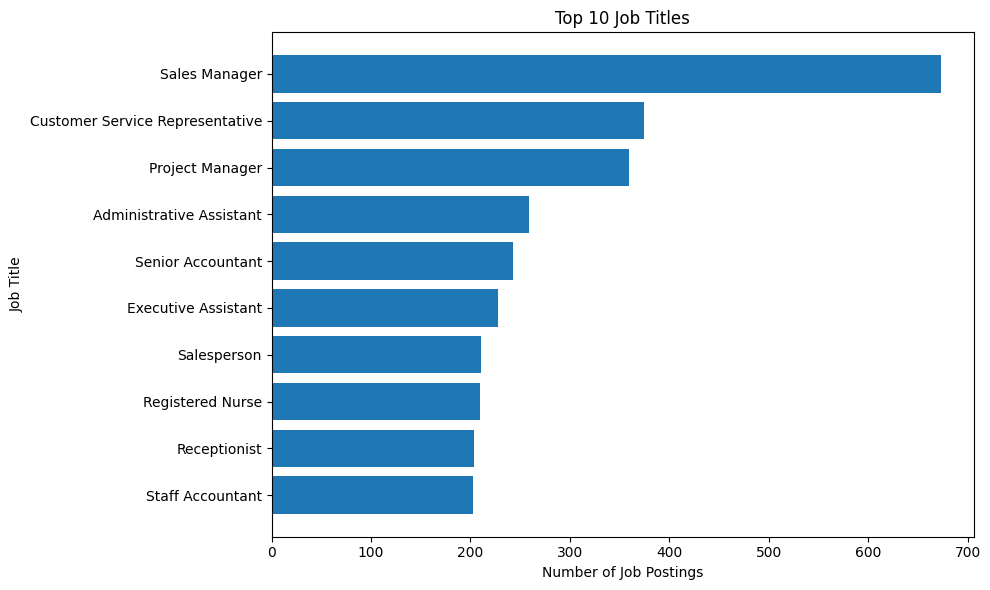

title,count
Sales Manager,673
Customer Service Representative,375
Project Manager,359
Administrative Assistant,259
Senior Accountant,243
Executive Assistant,228
Salesperson,211
Registered Nurse,210
Receptionist,204
Staff Accountant,203


In [0]:
top_titles = (
    jobs_clean.groupBy("title")
    .count()
    .orderBy(F.desc("count"))
    .limit(10)
)

top_titles_pd = top_titles.toPandas()

plt.figure(figsize=(10, 6))
plt.barh(top_titles_pd["title"], top_titles_pd["count"])
plt.title("Top 10 Job Titles")
plt.xlabel("Number of Job Postings")
plt.ylabel("Job Title")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

display(top_titles)

## 5.2 Top Hiring Companies

This chart shows which companies have the most postings in the dataset. This can help the agent recommend companies with higher hiring activity.

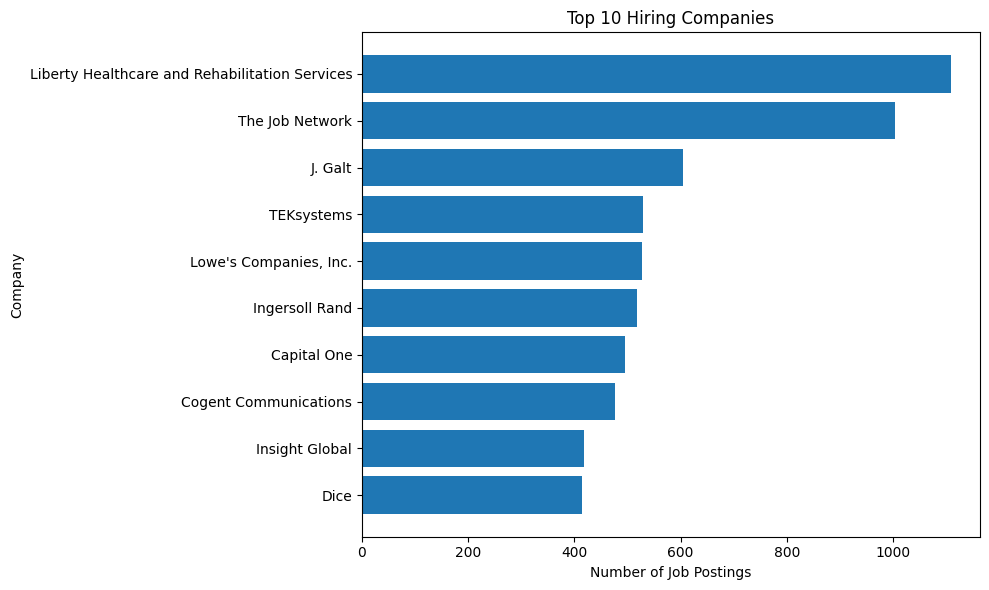

company_name,count
Liberty Healthcare and Rehabilitation Services,1108
The Job Network,1003
J. Galt,604
TEKsystems,529
"Lowe's Companies, Inc.",527
Ingersoll Rand,517
Capital One,496
Cogent Communications,476
Insight Global,418
Dice,415


In [0]:
top_companies = (
    jobs_clean
    .filter(F.col("company_name").isNotNull())
    .groupBy("company_name")
    .count()
    .orderBy(F.desc("count"))
    .limit(10)
)

top_companies_pd = top_companies.toPandas()

plt.figure(figsize=(10, 6))
plt.barh(top_companies_pd["company_name"], top_companies_pd["count"])
plt.title("Top 10 Hiring Companies")
plt.xlabel("Number of Job Postings")
plt.ylabel("Company")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

display(top_companies)

## 5.3 Top Job Locations

This chart shows the most common job locations. Location is important because the agent may need to filter jobs based on user preferences.

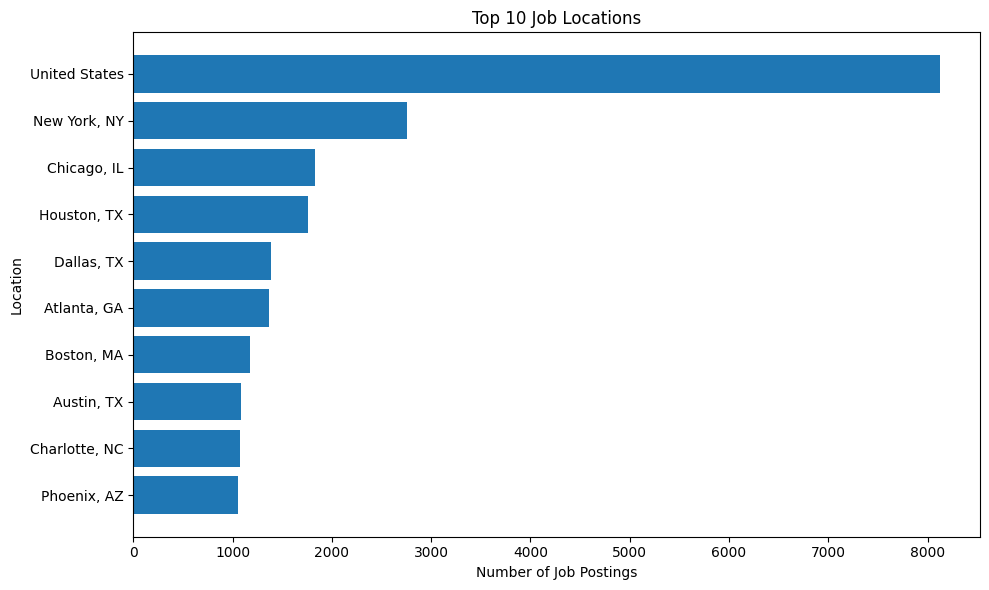

location,count
United States,8122
"New York, NY",2755
"Chicago, IL",1834
"Houston, TX",1762
"Dallas, TX",1383
"Atlanta, GA",1363
"Boston, MA",1176
"Austin, TX",1083
"Charlotte, NC",1075
"Phoenix, AZ",1059


In [0]:
top_locations = (
    jobs_clean
    .filter(F.col("location").isNotNull())
    .groupBy("location")
    .count()
    .orderBy(F.desc("count"))
    .limit(10)
)

top_locations_pd = top_locations.toPandas()

plt.figure(figsize=(10, 6))
plt.barh(top_locations_pd["location"], top_locations_pd["count"])
plt.title("Top 10 Job Locations")
plt.xlabel("Number of Job Postings")
plt.ylabel("Location")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

display(top_locations)

## 5.4 Remote vs Non-Remote Jobs

This chart compares remote and non-remote job postings. This is useful because many users may ask the agent to find remote opportunities.

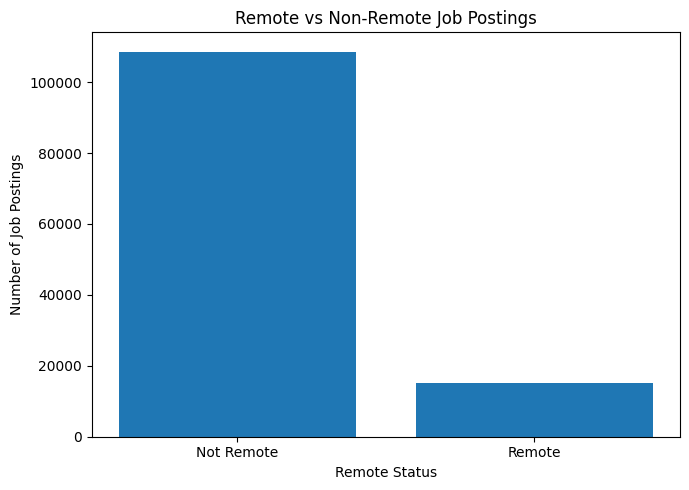

remote_status,count
Not Remote,108599
Remote,15243


In [0]:
remote_counts = (
    jobs_clean.groupBy("remote_status")
    .count()
    .orderBy(F.desc("count"))
)

remote_pd = remote_counts.toPandas()

plt.figure(figsize=(7, 5))
plt.bar(remote_pd["remote_status"], remote_pd["count"])
plt.title("Remote vs Non-Remote Job Postings")
plt.xlabel("Remote Status")
plt.ylabel("Number of Job Postings")
plt.tight_layout()
plt.show()

display(remote_counts)

## 5.5 Work Type Distribution

This chart shows the distribution of full-time, part-time, contract, internship, and other work types. This supports filtering and recommendation logic for the agent.

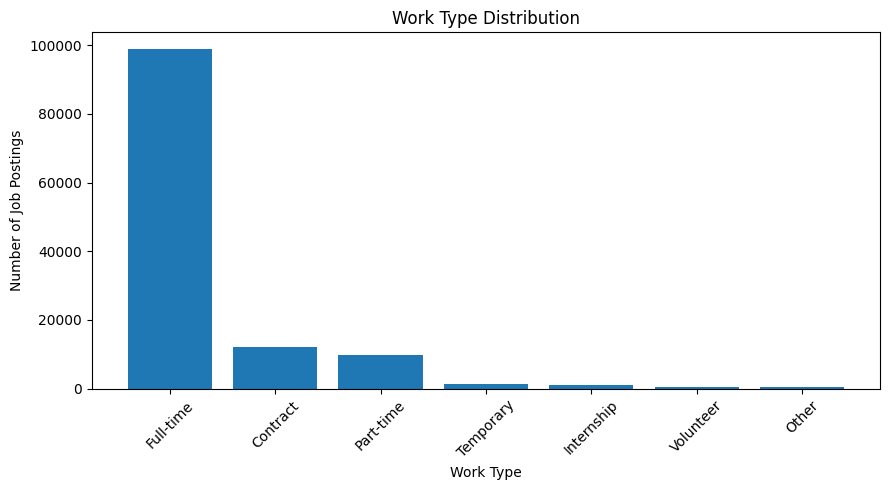

formatted_work_type,count
Full-time,98807
Contract,12117
Part-time,9696
Temporary,1190
Internship,983
Volunteer,562
Other,487


In [0]:
work_type_counts = (
    jobs_clean.groupBy("formatted_work_type")
    .count()
    .orderBy(F.desc("count"))
)

work_type_pd = work_type_counts.toPandas()

plt.figure(figsize=(9, 5))
plt.bar(work_type_pd["formatted_work_type"], work_type_pd["count"])
plt.title("Work Type Distribution")
plt.xlabel("Work Type")
plt.ylabel("Number of Job Postings")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

display(work_type_counts)

## 5.6 Salary Category Distribution

This chart groups salaries into simple ranges. It helps the agent explain salary levels in a user-friendly way.

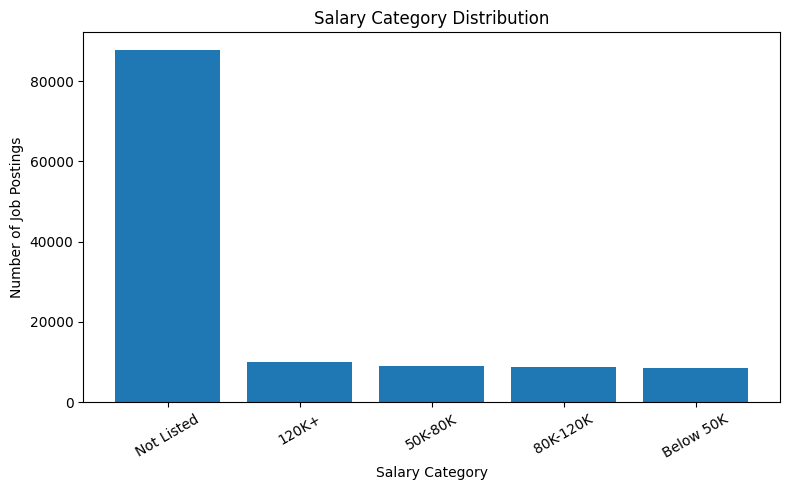

salary_category,count
Not Listed,87770
120K+,9904
50K-80K,9052
80K-120K,8713
Below 50K,8403


In [0]:
salary_category_counts = (
    jobs_clean.groupBy("salary_category")
    .count()
    .orderBy(F.desc("count"))
)

salary_category_pd = salary_category_counts.toPandas()

plt.figure(figsize=(8, 5))
plt.bar(salary_category_pd["salary_category"], salary_category_pd["count"])
plt.title("Salary Category Distribution")
plt.xlabel("Salary Category")
plt.ylabel("Number of Job Postings")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

display(salary_category_counts)

## 5.7 Top Paying Job Titles

This section identifies job titles with the highest average normalized salary. To avoid misleading results, only job titles with at least 10 postings are included.

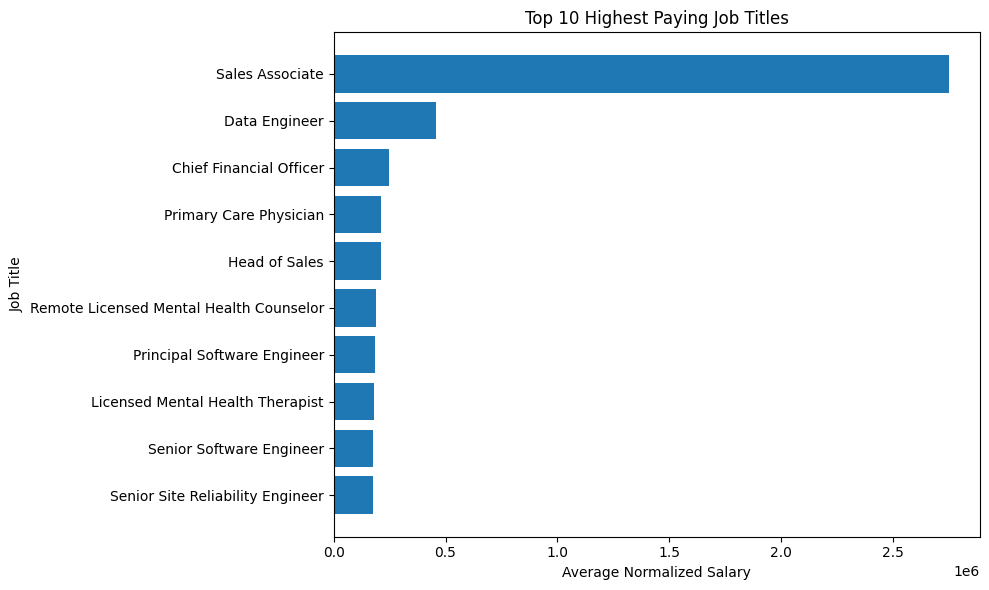

title,posting_count,avg_salary
Sales Associate,44,2751503.1
Data Engineer,21,455559.24
Chief Financial Officer,19,247500.0
Primary Care Physician,10,213750.0
Head of Sales,10,211900.0
Remote Licensed Mental Health Counselor,11,188334.55
Principal Software Engineer,10,186195.0
Licensed Mental Health Therapist,10,180856.0
Senior Software Engineer,57,175421.75
Senior Site Reliability Engineer,10,175392.0


In [0]:
top_paying_titles = (
    jobs_clean
    .filter(F.col("normalized_salary").isNotNull())
    .groupBy("title")
    .agg(
        F.count("*").alias("posting_count"),
        F.round(F.avg("normalized_salary"), 2).alias("avg_salary")
    )
    .filter(F.col("posting_count") >= 10)
    .orderBy(F.desc("avg_salary"))
    .limit(10)
)

top_paying_titles_pd = top_paying_titles.toPandas()

plt.figure(figsize=(10, 6))
plt.barh(top_paying_titles_pd["title"], top_paying_titles_pd["avg_salary"])
plt.title("Top 10 Highest Paying Job Titles")
plt.xlabel("Average Normalized Salary")
plt.ylabel("Job Title")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

display(top_paying_titles)

## 5.8 Top Paying Locations

This chart shows locations with the highest average normalized salary. Only locations with at least 10 postings are included to make the results more reliable.

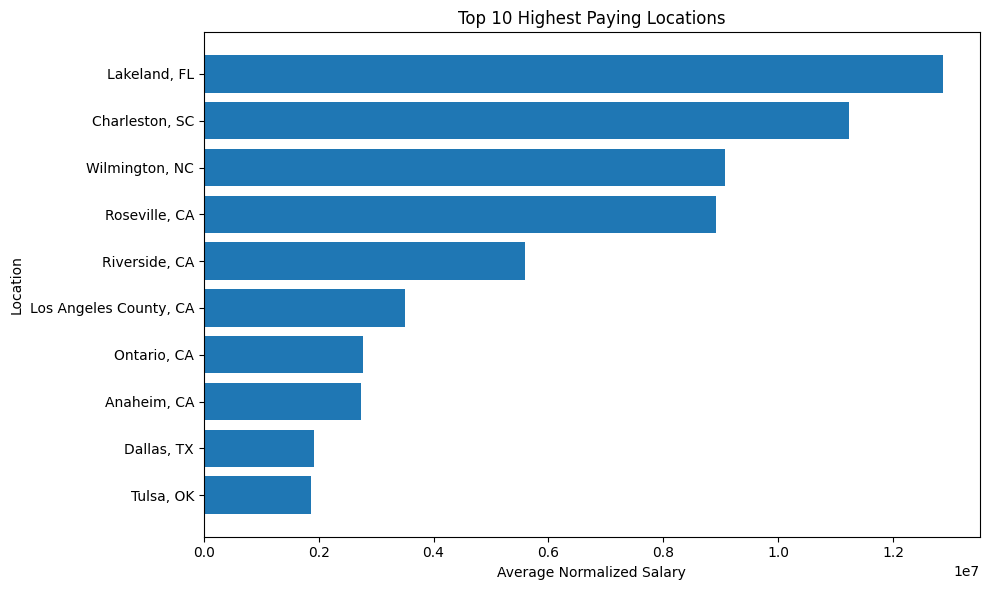

location,posting_count,avg_salary
"Lakeland, FL",18,1.28702061E7
"Charleston, SC",14,1.123083264E7
"Wilmington, NC",11,9067278.31
"Roseville, CA",41,8914855.03
"Riverside, CA",28,5594760.3
"Los Angeles County, CA",55,3511110.79
"Ontario, CA",35,2777021.91
"Anaheim, CA",51,2734817.37
"Dallas, TX",297,1911193.86
"Tulsa, OK",50,1871836.8


In [0]:
top_paying_locations = (
    jobs_clean
    .filter(F.col("normalized_salary").isNotNull())
    .groupBy("location")
    .agg(
        F.count("*").alias("posting_count"),
        F.round(F.avg("normalized_salary"), 2).alias("avg_salary")
    )
    .filter(F.col("posting_count") >= 10)
    .orderBy(F.desc("avg_salary"))
    .limit(10)
)

top_paying_locations_pd = top_paying_locations.toPandas()

plt.figure(figsize=(10, 6))
plt.barh(top_paying_locations_pd["location"], top_paying_locations_pd["avg_salary"])
plt.title("Top 10 Highest Paying Locations")
plt.xlabel("Average Normalized Salary")
plt.ylabel("Location")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

display(top_paying_locations)

# 6. Prepare Agent-Ready Search Text

This section creates a combined text field that can support semantic search, Vector Search, and retrieval-augmented generation. The search text combines job title, company, location, work type, salary category, and description into one searchable field.

In [0]:
jobs_agent_ready = jobs_clean.withColumn(
    "search_text",
    F.concat_ws(
        " ",
        F.col("title"),
        F.col("company_name"),
        F.col("location"),
        F.col("formatted_work_type"),
        F.col("remote_status"),
        F.col("salary_category"),
        F.col("description")
    )
)

display(
    jobs_agent_ready.select(
        "job_id",
        "title",
        "company_name",
        "location",
        "search_text"
    ).limit(5)
)

job_id title company_name location search_text 3530975184 Administrator of College & Career Development Education Success Foundation Rochester, NY Administrator of College & Career Development Education Success Foundation Rochester, NY Full-time Not Remote 50K-80K Are you ready to lead Rochester teens toward their brightest futures? EnCompass seeks a dynamic Administrator of College and Career Development to spearhead our innovative out-of-school time initiatives. In this pivotal role, you'll equip middle and high school students for success in school and beyond. Collaborating closely with program coordinators and staff, you'll drive the implementation of our holistic approach to education, encompassing academic support, social-emotional enrichment, college and career exposure, job placement, and personalized mentorship. As a key member of our leadership team, you'll provide insights to refine program design and performance metrics, championing evidence-based models and continuous improvement. Your impact will extend beyond our organization as you forge meaningful partnerships within the community, representing EnCompass in youth engagement, college readiness, and workforce development initiatives. If you're passionate about youth development, fostering collaboration, and driving positive change, join us today.
SUMMARY:The Administrator of College and Career Development will oversee EnCompass’ comprehensive youth development programs. This administrator will collaborate with program coordinators and staff to ensure these programs are implemented with fidelity to EnCompass’ mission to prepare students for success in school and life. With a focus on college and career readiness, the person in this role will support a whole-child model inclusive of academic tutoring, social-emotional enrichments, college and career exposures, job placement, and one-to-one mentorship. Senior organizational leadership will look to this administrator for feedback and guidance on program design and performance measures with an emphasis on evidence-based models and continuous improvement. As a member of the EnCompass leadership team, the administrator will collaborate with colleagues to promote cross-program alignment and will also supervise program coordinators and navigators who provide direct service to youth.
JOB RESPONSIBILITIES: Oversee Youth Development ProgrammingReview program-specific foundational documents including, but not limited to, logic models, participant agreements, and partner-facing program overviews to align with organizational goals and best practices in youth development; revise when appropriate.Solicit, incorporate, and prioritize youth voice and feedback in program design and continuous improvement.Work with program coordinators to ensure programs are implemented as designed; support coordinators and front-line staff in day-to-day operations by observing, participating in, and debriefing program events and activities regularly, including mandatory attendance on an annual multi-day overnight college tour trip.Uphold protocols that ensure the safety of all program participants and staff.Develop and monitor program budgets to reflect and appropriately utilize relevant funding; partner with coordinators to track spending.Collaborate with program coordinators to create a clear profile of the appropriate participants and corresponding recruitment strategies to reach enrollment targets.Work with Data & Evaluation Manager and Director to identify evidence-based program measures; monitor progress toward articulated outcomes; adjust when necessary.Manage Relevant Community Partnerships and Represent EnCompass in the CommunityFoster effective collaboration with existing schools (K-12s and colleges) and community partners; work with partners to brainstorm and execute action steps for addressing issues facing youth.Collaborate with program coordinators to identify appropriate schools, employers, agencies, and providers for new partnership

# 7. Save Agent-Ready Tables

This section saves the cleaned and prepared datasets as Delta tables in Unity Catalog. These tables will be used by the AI Engineering portion of the project for retrieval, filtering, and recommendation generation.

In [0]:
jobs_agent_ready.write.format("delta") \
    .mode("overwrite") \
    .option("overwriteSchema", "true") \
    .saveAsTable("finalproject.careermatch_ai.jobs_gold")

jobs_agent_ready.select(
    "job_id",
    "title",
    "company_name",
    "location",
    "formatted_work_type",
    "remote_status",
    "salary_category",
    "normalized_salary",
    "description",
    "search_text",
    "job_posting_url"
).write.format("delta") \
    .mode("overwrite") \
    .option("overwriteSchema", "true") \
    .saveAsTable("finalproject.careermatch_ai.jobs_vector_ready")

SECTION 2 

Career Gap Analysis System
Overview
This notebook implements a comprehensive Career Gap Analysis system that matches user profiles with job postings from the jobs_gold table. The system analyzes skills, identifies gaps, and provides personalized recommendations for career advancement.

Key Features
Automated Skill Extraction: Uses a taxonomy of 108+ skills across 9 categories
Gap Analysis: Calculates match scores and identifies missing skills
Smart Recommendations: Provides actionable advice based on skill gaps
Batch Processing: Analyzes multiple users against multiple jobs efficiently
Export Capabilities: Generates CSV reports and PDF summaries
Data Sources
User Profiles: finalproject.careermatch_ai.user_profiles (3 sample users)
Job Postings: finalproject.careermatch_ai.jobs_gold (123,842 jobs)
How It Works
Define Skill Taxonomy - Create a comprehensive list of technical and soft skills
Extract Skills - Parse job descriptions to identify required skills
Match & Score - Compare user skills against job requirements
Generate Insights - Provide match scores and skill gap analysis
Export Results - Create reports for sharing with stakeholders
Section 1: Database Setup
What This Cell Does
Creates the user_profiles table in Unity Catalog to store candidate information for career matching.

Table Structure
user_id: Unique identifier for each user
name, email: Basic contact information
current_skills: Array of skills the user possesses (e.g., ['Python', 'SQL', 'Leadership'])
education: Highest degree obtained
experience_years: Total years of professional experience
current_role: User's current job title
desired_role: Target position they're seeking
certifications: Professional credentials (e.g., ['AWS Certified', 'PMP'])
resume_text: Full resume content for detailed text analysis
created_at: Timestamp of profile creation

In [0]:
%sql
-- Create user_profiles table in finalproject.careermatch_ai schema
CREATE TABLE IF NOT EXISTS finalproject.careermatch_ai.user_profiles (
  user_id STRING NOT NULL,
  name STRING,
  email STRING,
  current_skills ARRAY<STRING> COMMENT 'List of current skills the user possesses',
  education STRING COMMENT 'Highest degree obtained',
  experience_years INT COMMENT 'Total years of professional experience',
  current_role STRING COMMENT 'Current job title',
  desired_role STRING COMMENT 'Target job title user is seeking',
  certifications ARRAY<STRING> COMMENT 'Professional certifications',
  resume_text STRING COMMENT 'Full resume content for detailed analysis',
  created_at TIMESTAMP
)
COMMENT 'User profile data for career gap analysis and job matching'

In [0]:
%sql
-- Insert sample user profiles with diverse backgrounds
INSERT INTO finalproject.careermatch_ai.user_profiles 
  (user_id, name, email, current_skills, education, experience_years, current_role, desired_role, certifications, resume_text, created_at)
VALUES
  (
    'user_001',
    'Sarah Johnson',
    'sarah.johnson@email.com',
    array('Python', 'SQL', 'Data Analysis', 'Excel', 'Tableau', 'Communication', 'Problem Solving'),
    'Bachelor of Science in Business Analytics',
    2,
    'Junior Data Analyst',
    'Data Scientist',
    array('Google Data Analytics Certificate'),
    'Junior Data Analyst with 2 years experience in business intelligence and data visualization. Proficient in Python, SQL, and Tableau. Strong analytical and communication skills. Seeking to transition into data science role.',
    current_timestamp()
  ),
  (
    'user_002',
    'Michael Chen',
    'michael.chen@email.com',
    array('Java', 'JavaScript', 'React', 'Node.js', 'Git', 'Agile', 'REST APIs', 'MongoDB'),
    'Bachelor of Science in Computer Science',
    5,
    'Full Stack Developer',
    'Senior Software Engineer',
    array('AWS Certified Developer', 'Scrum Master Certified'),
    'Full Stack Developer with 5 years experience building scalable web applications. Expertise in React, Node.js, and cloud deployment. Looking for senior engineering roles with leadership opportunities.',
    current_timestamp()
  ),
  (
    'user_003',
    'Emily Rodriguez',
    'emily.rodriguez@email.com',
    array('Project Management', 'Stakeholder Communication', 'Budgeting', 'Risk Management', 'Microsoft Office', 'Leadership'),
    'Master of Business Administration',
    3,
    'Project Coordinator',
    'Project Manager',
    array('PMP Certification', 'Six Sigma Green Belt'),
    'Project Coordinator with 3 years coordinating cross-functional teams and managing project timelines. MBA graduate with PMP certification. Seeking project management role in tech industry.',
    current_timestamp()
  )

num_affected_rows,num_inserted_rows
3,3


In [0]:
# Comprehensive skill taxonomy for extraction
SKILL_TAXONOMY = {
    'programming_languages': [
        'Python', 'Java', 'JavaScript', 'C++', 'C#', 'Ruby', 'Go', 'Rust', 'Swift',
        'Kotlin', 'TypeScript', 'PHP', 'R', 'Scala', 'Perl', 'MATLAB'
    ],
    'data_science': [
        'Machine Learning', 'Deep Learning', 'NLP', 'Computer Vision', 'Data Mining',
        'Statistical Analysis', 'Predictive Modeling', 'Neural Networks', 'TensorFlow',
        'PyTorch', 'Scikit-learn', 'Keras', 'Data Visualization', 'Feature Engineering'
    ],
    'databases': [
        'SQL', 'MySQL', 'PostgreSQL', 'MongoDB', 'Oracle', 'SQL Server', 'Redis',
        'Cassandra', 'DynamoDB', 'NoSQL', 'Database Design', 'Data Warehousing'
    ],
    'cloud_platforms': [
        'AWS', 'Azure', 'Google Cloud', 'GCP', 'Cloud Computing', 'Docker',
        'Kubernetes', 'Serverless', 'Lambda', 'EC2', 'S3'
    ],
    'web_development': [
        'HTML', 'CSS', 'React', 'Angular', 'Vue.js', 'Node.js', 'Django', 'Flask',
        'REST API', 'GraphQL', 'Web Services', 'Frontend', 'Backend', 'Full Stack'
    ],
    'data_tools': [
        'Tableau', 'Power BI', 'Excel', 'Spark', 'Hadoop', 'Databricks', 'Airflow',
        'ETL', 'Data Pipeline', 'Pandas', 'NumPy'
    ],
    'soft_skills': [
        'Communication', 'Leadership', 'Problem Solving', 'Teamwork', 'Critical Thinking',
        'Analytical Skills', 'Project Management', 'Time Management', 'Collaboration',
        'Adaptability', 'Creativity', 'Attention to Detail'
    ],
    'methodologies': [
        'Agile', 'Scrum', 'Kanban', 'DevOps', 'CI/CD', 'Test Driven Development',
        'Microservices', 'Waterfall', 'Lean'
    ],
    'certifications': [
        'AWS Certified', 'Azure Certified', 'PMP', 'Scrum Master', 'Six Sigma',
        'Google Analytics', 'Salesforce', 'CompTIA', 'CISSP'
    ]
}

# Flatten all skills into a single list for matching
ALL_SKILLS = [skill for category in SKILL_TAXONOMY.values() for skill in category]

print(f"Skill taxonomy loaded with {len(ALL_SKILLS)} skills across {len(SKILL_TAXONOMY)} categories")

Skill taxonomy loaded with 108 skills across 9 categories


In [0]:
import re
from typing import List, Set

def extract_skills_from_text(text: str) -> List[str]:
    """
    Extract skills from job description text using keyword matching.
    
    Args:
        text: Job description or resume text
        
    Returns:
        List of unique skills found in the text
    """
    if not text:
        return []
    
    # Convert to lowercase for case-insensitive matching
    text_lower = text.lower()
    found_skills = set()
    
    # Check each skill in taxonomy
    for skill in ALL_SKILLS:
        # Use word boundary matching to avoid partial matches
        pattern = r'\b' + re.escape(skill.lower()) + r'\b'
        if re.search(pattern, text_lower):
            found_skills.add(skill)
    
    return sorted(list(found_skills))

def extract_skills_from_jobs(job_df):
    """
    Extract skills from a DataFrame of job postings.
    
    Args:
        job_df: Spark DataFrame with 'job_id' and 'description' columns
        
    Returns:
        Spark DataFrame with job_id and extracted_skills columns
    """
    from pyspark.sql.functions import udf
    from pyspark.sql.types import ArrayType, StringType
    
    # Register UDF for skill extraction
    extract_skills_udf = udf(extract_skills_from_text, ArrayType(StringType()))
    
    # Apply to description column
    result_df = job_df.select(
        'job_id',
        'title',
        'company_name',
        extract_skills_udf('description').alias('required_skills')
    )
    
    return result_df

# Test the function with sample text
sample_job_text = "We are looking for a Data Scientist with strong Python and SQL skills. Experience with Machine Learning, TensorFlow, and AWS is required. Must have excellent communication and problem solving abilities."
extracted = extract_skills_from_text(sample_job_text)
print(f"\nExtracted skills from sample text: {extracted}")


Extracted skills from sample text: ['AWS', 'Communication', 'Machine Learning', 'Problem Solving', 'Python', 'SQL', 'TensorFlow']


In [0]:
from typing import Dict, List, Tuple

def analyze_career_gap(user_skills: List[str], job_required_skills: List[str]) -> Dict:
    """
    Analyze the gap between user skills and job requirements.
    
    Args:
        user_skills: List of skills the user currently has
        job_required_skills: List of skills required for the job
        
    Returns:
        Dictionary containing gap analysis results
    """
    user_skills_set = set([s.lower() for s in user_skills])
    job_skills_set = set([s.lower() for s in job_required_skills])
    
    # Calculate matches and gaps
    matching_skills = user_skills_set.intersection(job_skills_set)
    missing_skills = job_skills_set - user_skills_set
    extra_skills = user_skills_set - job_skills_set
    
    # Calculate match score
    if len(job_skills_set) > 0:
        match_score = (len(matching_skills) / len(job_skills_set)) * 100
    else:
        match_score = 0.0
    
    # Categorize missing skills by type
    categorized_gaps = {}
    for skill in missing_skills:
        for category, skills_list in SKILL_TAXONOMY.items():
            if any(s.lower() == skill for s in skills_list):
                if category not in categorized_gaps:
                    categorized_gaps[category] = []
                # Find original case
                original_skill = next(s for s in skills_list if s.lower() == skill)
                categorized_gaps[category].append(original_skill)
                break
    
    return {
        'match_score': round(match_score, 2),
        'matching_skills': sorted([s for s in job_required_skills if s.lower() in matching_skills]),
        'missing_skills': sorted([s for s in job_required_skills if s.lower() in missing_skills]),
        'extra_skills': sorted([s for s in user_skills if s.lower() in extra_skills]),
        'categorized_gaps': categorized_gaps,
        'total_required': len(job_skills_set),
        'total_matched': len(matching_skills),
        'total_missing': len(missing_skills)
    }

def get_recommendations(gap_analysis: Dict) -> List[str]:
    """
    Generate actionable recommendations based on gap analysis.
    
    Args:
        gap_analysis: Output from analyze_career_gap function
        
    Returns:
        List of recommendation strings
    """
    recommendations = []
    
    match_score = gap_analysis['match_score']
    
    # Overall assessment
    if match_score >= 80:
        recommendations.append(f" Excellent match! You meet {match_score}% of the requirements.")
    elif match_score >= 60:
        recommendations.append(f"Good match! You meet {match_score}% of the requirements.")
    elif match_score >= 40:
        recommendations.append(f"⚠ Moderate match. You meet {match_score}% of the requirements.")
    else:
        recommendations.append(f"⚠ Low match. You meet only {match_score}% of the requirements.")
    
    # Priority skill gaps
    if gap_analysis['missing_skills']:
        recommendations.append(f"\n Priority Skills to Develop ({len(gap_analysis['missing_skills'])} skills):")
        
        # Categorize recommendations
        categorized = gap_analysis['categorized_gaps']
        
        if 'programming_languages' in categorized:
            langs = ', '.join(categorized['programming_languages'][:3])
            recommendations.append(f"  • Programming: Learn {langs}")
            
        if 'data_science' in categorized:
            ds_skills = ', '.join(categorized['data_science'][:3])
            recommendations.append(f"  • Data Science: Develop {ds_skills} skills")
            
        if 'cloud_platforms' in categorized:
            cloud = ', '.join(categorized['cloud_platforms'][:3])
            recommendations.append(f"  • Cloud: Get certified in {cloud}")
            
        if 'databases' in categorized:
            db = ', '.join(categorized['databases'][:3])
            recommendations.append(f"  • Databases: Gain experience with {db}")
    
    # Leverage existing skills
    if gap_analysis['matching_skills']:
        top_matches = ', '.join(gap_analysis['matching_skills'][:5])
        recommendations.append(f"\n Highlight These Matching Skills: {top_matches}")
    
    return recommendations

print("Career gap analysis functions defined successfully!")

Career gap analysis functions defined successfully!


In [0]:
def perform_gap_analysis(user_id: str, job_id: int) -> Dict:
    """
    Perform complete career gap analysis for a user and job combination.
    
    Args:
        user_id: User identifier
        job_id: Job posting identifier
        
    Returns:
        Complete gap analysis with recommendations
    """
    # Fetch user profile
    user_query = f"""
    SELECT * FROM finalproject.careermatch_ai.user_profiles 
    WHERE user_id = '{user_id}'
    """
    user_df = spark.sql(user_query)
    
    if user_df.count() == 0:
        return {"error": f"User {user_id} not found"}
    
    user_row = user_df.first()
    
    # Fetch job details
    job_query = f"""
    SELECT * FROM finalproject.careermatch_ai.jobs_gold 
    WHERE job_id = {job_id}
    """
    job_df = spark.sql(job_query)
    
    if job_df.count() == 0:
        return {"error": f"Job {job_id} not found"}
    
    job_row = job_df.first()
    
    # Extract skills from job description
    job_skills = extract_skills_from_text(job_row['description'])
    
    # Perform gap analysis
    gap_analysis = analyze_career_gap(user_row['current_skills'], job_skills)
    
    # Get recommendations
    recommendations = get_recommendations(gap_analysis)
    
    # Compile complete result
    result = {
        'user_info': {
            'name': user_row['name'],
            'current_role': user_row['current_role'],
            'desired_role': user_row['desired_role'],
            'experience_years': user_row['experience_years'],
            'education': user_row['education']
        },
        'job_info': {
            'job_id': job_row['job_id'],
            'title': job_row['title'],
            'company': job_row['company_name'],
            'location': job_row['location'],
            'remote_status': job_row['remote_status']
        },
        'gap_analysis': gap_analysis,
        'recommendations': recommendations
    }
    
    return result

def display_gap_analysis(result: Dict):
    """
    Display gap analysis results in a readable format.
    """
    if 'error' in result:
        print(f" Error: {result['error']}")
        return
    
    print("="*80)
    print("CAREER GAP ANALYSIS REPORT")
    print("="*80)
    
    # User Info
    user = result['user_info']
    print(f"\n CANDIDATE: {user['name']}")
    print(f"   Current Role: {user['current_role']}")
    print(f"   Desired Role: {user['desired_role']}")
    print(f"   Experience: {user['experience_years']} years")
    print(f"   Education: {user['education']}")
    
    # Job Info
    job = result['job_info']
    print(f"\n TARGET JOB:")
    print(f"   Title: {job['title']}")
    print(f"   Company: {job['company']}")
    print(f"   Location: {job['location']}")
    print(f"   Remote: {job['remote_status']}")
    
    # Gap Analysis
    gap = result['gap_analysis']
    print(f"\n MATCH ANALYSIS:")
    print(f"   Match Score: {gap['match_score']}%")
    print(f"   Skills Matched: {gap['total_matched']} / {gap['total_required']}")
    print(f"   Skills Missing: {gap['total_missing']}")
    
    print(f"\n MATCHING SKILLS ({len(gap['matching_skills'])}):")
    print(f"   {', '.join(gap['matching_skills']) if gap['matching_skills'] else 'None'}")
    
    print(f"\n MISSING SKILLS ({len(gap['missing_skills'])}):")
    print(f"   {', '.join(gap['missing_skills']) if gap['missing_skills'] else 'None'}")
    
    print(f"\n ADDITIONAL SKILLS ({len(gap['extra_skills'])}):")
    print(f"   {', '.join(gap['extra_skills'][:10]) if gap['extra_skills'] else 'None'}")
    
    # Recommendations
    print(f"\n RECOMMENDATIONS:")
    for rec in result['recommendations']:
        print(f"   {rec}")
    
    print("\n" + "="*80)

print("Gap analysis pipeline functions ready!")

Gap analysis pipeline functions ready!


In [0]:
# Let's pick the first job from the table and analyze Sarah's fit
# Get the first job_id
first_job = spark.sql("""
    SELECT job_id 
    FROM finalproject.careermatch_ai.jobs_gold 
    LIMIT 1
""").first()

if first_job:
    job_id_to_analyze = first_job['job_id']
    print(f"Analyzing user_001 (Sarah Johnson) against job_id: {job_id_to_analyze}\n")
    
    # Perform gap analysis
    result = perform_gap_analysis('user_001', job_id_to_analyze)
    
    # Display results
    display_gap_analysis(result)
else:
    print("No jobs found in the table")

Analyzing user_001 (Sarah Johnson) against job_id: 3458210342

CAREER GAP ANALYSIS REPORT

 CANDIDATE: Sarah Johnson
   Current Role: Junior Data Analyst
   Desired Role: Data Scientist
   Experience: 2 years
   Education: Bachelor of Science in Business Analytics

 TARGET JOB:
   Title: Clinical Trainee / Pre-Liscneded Therapist
   Company: Fraser
   Location: Greater Minneapolis-St. Paul Area
   Remote: Not Remote

 MATCH ANALYSIS:
   Match Score: 50.0%
   Skills Matched: 1 / 2
   Skills Missing: 1

 MATCHING SKILLS (1):
   Communication

 MISSING SKILLS (1):
   Leadership

 ADDITIONAL SKILLS (6):
   Data Analysis, Excel, Problem Solving, Python, SQL, Tableau

 RECOMMENDATIONS:
   ⚠ Moderate match. You meet 50.0% of the requirements.
   
 Priority Skills to Develop (1 skills):
   
 Highlight These Matching Skills: Communication



In [0]:
# Compare all three users against the same job to see who's the best fit
print("\n" + "#"*80)
print("COMPARATIVE ANALYSIS: All Users vs Same Job")
print("#"*80 + "\n")

if first_job:
    users = ['user_001', 'user_002', 'user_003']
    
    comparison_results = []
    
    for user_id in users:
        result = perform_gap_analysis(user_id, job_id_to_analyze)
        if 'error' not in result:
            comparison_results.append({
                'user_name': result['user_info']['name'],
                'current_role': result['user_info']['current_role'],
                'match_score': result['gap_analysis']['match_score'],
                'matched_skills': result['gap_analysis']['total_matched'],
                'missing_skills': result['gap_analysis']['total_missing']
            })
    
    # Display comparison
    import pandas as pd
    comparison_df = pd.DataFrame(comparison_results)
    comparison_df = comparison_df.sort_values('match_score', ascending=False)
    
    print("\n RANKING BY MATCH SCORE:\n")
    display(comparison_df)


################################################################################
COMPARATIVE ANALYSIS: All Users vs Same Job
################################################################################


 RANKING BY MATCH SCORE:



user_name,current_role,match_score,matched_skills,missing_skills
Sarah Johnson,Junior Data Analyst,50.0,1,1
Emily Rodriguez,Project Coordinator,50.0,1,1
Michael Chen,Full Stack Developer,0.0,0,2


In [0]:
# Create a detailed view showing what skills each user needs
print("\n" + "="*80)
print("DETAILED SKILLS GAP BREAKDOWN")
print("="*80 + "\n")

if first_job:
    for user_id in users:
        result = perform_gap_analysis(user_id, job_id_to_analyze)
        if 'error' not in result:
            print(f"\n {result['user_info']['name']} - {result['user_info']['current_role']}")
            print(f"   Match Score: {result['gap_analysis']['match_score']}%")
            print(f"   Missing Skills ({result['gap_analysis']['total_missing']}): {', '.join(result['gap_analysis']['missing_skills'][:8])}")
            if len(result['gap_analysis']['missing_skills']) > 8:
                print(f"      ... and {len(result['gap_analysis']['missing_skills']) - 8} more")
            print()


DETAILED SKILLS GAP BREAKDOWN


 Sarah Johnson - Junior Data Analyst
   Match Score: 50.0%
   Missing Skills (1): Leadership


 Michael Chen - Full Stack Developer
   Match Score: 0.0%
   Missing Skills (2): Communication, Leadership


 Emily Rodriguez - Project Coordinator
   Match Score: 50.0%
   Missing Skills (1): Communication



In [0]:
print("""
╔════════════════════════════════════════════════════════════════════════════╗
║                    CAREER GAP ANALYSIS SYSTEM - USAGE GUIDE               ║
╚════════════════════════════════════════════════════════════════════════════╝

SYSTEM COMPONENTS:
   User Profile Table: finalproject.careermatch_ai.user_profiles
   Jobs Table: finalproject.careermatch_ai.jobs_vector_ready
   Skill Taxonomy: 108 skills across 9 categories
   Gap Analysis Functions: Ready to use

KEY FUNCTIONS:
   1. extract_skills_from_text(text) 
      - Extract skills from any text (job description, resume)
      
   2. analyze_career_gap(user_skills, job_skills)
      - Compare skills and calculate match score
      
   3. perform_gap_analysis(user_id, job_id)
      - Complete end-to-end analysis with recommendations
      
   4. display_gap_analysis(result)
      - Pretty-print analysis results

USAGE EXAMPLES:

   # Analyze a specific user-job combination
   result = perform_gap_analysis('user_001', 2457183642)
   display_gap_analysis(result)
   
   # Extract skills from custom text
   skills = extract_skills_from_text("Looking for Python developer with SQL and AWS")
   print(skills)
   
   # Add new user profile
   spark.sql('''
   INSERT INTO finalproject.careermatch_ai.user_profiles VALUES (
     'user_004', 'John Doe', 'john@email.com',
     array('Python', 'Machine Learning', 'TensorFlow'),
     'MS in Data Science', 3, 'Data Analyst', 'ML Engineer',
     array('AWS Certified'), 'Resume text here', current_timestamp()
   )
   ''')

 NEXT STEPS:
   • Add more user profiles to your database
   • Run gap analysis for different job postings
   • Export results for reporting
   • Integrate with your job recommendation system
   • Build a UI/dashboard on top of these functions

""")


╔════════════════════════════════════════════════════════════════════════════╗
║                    CAREER GAP ANALYSIS SYSTEM - USAGE GUIDE               ║
╚════════════════════════════════════════════════════════════════════════════╝

SYSTEM COMPONENTS:
   ✓ User Profile Table: finalproject.careermatch_ai.user_profiles
   ✓ Jobs Table: finalproject.careermatch_ai.jobs_vector_ready
   ✓ Skill Taxonomy: 108 skills across 9 categories
   ✓ Gap Analysis Functions: Ready to use

KEY FUNCTIONS:
   1. extract_skills_from_text(text) 
      - Extract skills from any text (job description, resume)
      
   2. analyze_career_gap(user_skills, job_skills)
      - Compare skills and calculate match score
      
   3. perform_gap_analysis(user_id, job_id)
      - Complete end-to-end analysis with recommendations
      
   4. display_gap_analysis(result)
      - Pretty-print analysis results

USAGE EXAMPLES:

   # Analyze a specific user-job combination
   result = perform_gap_analysis('user_001',

In [0]:
# Sample jobs from the database for analysis
print(" Sampling jobs from the database...")
jobs_to_analyze = spark.sql("""
    SELECT job_id, title, company_name, location, remote_status, description
    FROM finalproject.careermatch_ai.jobs_gold
    LIMIT 100
""").collect()

print(f"Loaded {len(jobs_to_analyze)} jobs from jobs_gold table\n")

# Store results for each user
all_user_matches = {}

for user_id in users:
    print(f"\n Analyzing jobs for {user_id}...")
    
    user_matches = []
    
    # Analyze each job for this user
    for job in jobs_to_analyze:
        result = perform_gap_analysis(user_id, job['job_id'])
        
        if 'error' not in result:
            user_matches.append({
                'user_id': user_id,
                'user_name': result['user_info']['name'],
                'current_role': result['user_info']['current_role'],
                'desired_role': result['user_info']['desired_role'],
                'job_id': job['job_id'],
                'job_title': result['job_info']['title'],
                'company': result['job_info']['company'],
                'location': result['job_info']['location'],
                'remote_status': result['job_info']['remote_status'],
                'match_score': result['gap_analysis']['match_score'],
                'matched_skills': result['gap_analysis']['total_matched'],
                'missing_skills': result['gap_analysis']['total_missing'],
                'total_required': result['gap_analysis']['total_required']
            })
    
    all_user_matches[user_id] = user_matches
    print(f"  Analyzed {len(user_matches)} jobs")

print("\n" + "="*80)
print("Analysis Complete!\n")

 Sampling jobs from the database...
✓ Loaded 100 jobs from jobs_gold table


Analyzing jobs for user_001...
  ✓ Analyzed 100 jobs

Analyzing jobs for user_002...
  ✓ Analyzed 100 jobs

Analyzing jobs for user_003...
  ✓ Analyzed 100 jobs

Analysis Complete!



In [0]:
# ==============================================================================
# EXPLORATORY DATA ANALYSIS - USER PROFILES
# ==============================================================================

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

# Set visualization style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10

print("EXPLORATORY DATA ANALYSIS - USER PROFILES")
print("="*80)

# Load user profiles from Unity Catalog
user_profiles_df = spark.sql("""
    SELECT * FROM finalproject.careermatch_ai.user_profiles
""").toPandas()

print(f"\n✓ Loaded {len(user_profiles_df)} user profiles\n")
print("DATASET PREVIEW:")
print("="*80)
display(user_profiles_df)

# Display schema information
print("\n" + "="*80)
print("DATA TYPES:")
print("="*80)
print(user_profiles_df.dtypes)
print(f"\nDataset Shape: {user_profiles_df.shape[0]} rows × {user_profiles_df.shape[1]} columns")

EXPLORATORY DATA ANALYSIS - USER PROFILES

✓ Loaded 23 user profiles

DATASET PREVIEW:


user_id,name,email,current_skills,education,experience_years,current_role,desired_role,certifications,resume_text,created_at
user_001,Sarah Johnson,sarah.johnson@email.com,"List(Python, SQL, Data Analysis, Excel, Tableau, Communication, Problem Solving)",Bachelor of Science in Business Analytics,2,Junior Data Analyst,Data Scientist,List(Google Data Analytics Certificate),"Junior Data Analyst with 2 years experience in business intelligence and data visualization. Proficient in Python, SQL, and Tableau. Strong analytical and communication skills. Seeking to transition into data science role.",2026-06-14T08:03:38.473Z
user_002,Michael Chen,michael.chen@email.com,"List(Java, JavaScript, React, Node.js, Git, Agile, REST APIs, MongoDB)",Bachelor of Science in Computer Science,5,Full Stack Developer,Senior Software Engineer,"List(AWS Certified Developer, Scrum Master Certified)","Full Stack Developer with 5 years experience building scalable web applications. Expertise in React, Node.js, and cloud deployment. Looking for senior engineering roles with leadership opportunities.",2026-06-14T08:03:38.473Z
user_003,Emily Rodriguez,emily.rodriguez@email.com,"List(Project Management, Stakeholder Communication, Budgeting, Risk Management, Microsoft Office, Leadership)",Master of Business Administration,3,Project Coordinator,Project Manager,"List(PMP Certification, Six Sigma Green Belt)",Project Coordinator with 3 years coordinating cross-functional teams and managing project timelines. MBA graduate with PMP certification. Seeking project management role in tech industry.,2026-06-14T08:03:38.473Z
user_001,Sarah Johnson,sarah.johnson@email.com,"List(Python, SQL, Data Analysis, Excel, Tableau, Communication, Problem Solving)",Bachelor of Science in Business Analytics,2,Junior Data Analyst,Data Scientist,List(Google Data Analytics Certificate),"Junior Data Analyst with 2 years experience in business intelligence and data visualization. Proficient in Python, SQL, and Tableau. Strong analytical and communication skills. Seeking to transition into data science role.",2026-06-14T04:14:19.719Z
user_002,Michael Chen,michael.chen@email.com,"List(Java, JavaScript, React, Node.js, Git, Agile, REST APIs, MongoDB)",Bachelor of Science in Computer Science,5,Full Stack Developer,Senior Software Engineer,"List(AWS Certified Developer, Scrum Master Certified)","Full Stack Developer with 5 years experience building scalable web applications. Expertise in React, Node.js, and cloud deployment. Looking for senior engineering roles with leadership opportunities.",2026-06-14T04:14:19.719Z
user_003,Emily Rodriguez,emily.rodriguez@email.com,"List(Project Management, Stakeholder Communication, Budgeting, Risk Management, Microsoft Office, Leadership)",Master of Business Administration,3,Project Coordinator,Project Manager,"List(PMP Certification, Six Sigma Green Belt)",Project Coordinator with 3 years coordinating cross-functional teams and managing project timelines. MBA graduate with PMP certification. Seeking project management role in tech industry.,2026-06-14T04:14:19.719Z
user_001,Sarah Johnson,sarah.johnson@email.com,"List(Python, SQL, Data Analysis, Excel, Tableau, Communication, Problem Solving)",Bachelor of Science in Business Analytics,2,Junior Data Analyst,Data Scientist,List(Google Data Analytics Certificate),"Junior Data Analyst with 2 years experience in business intelligence and data visualization. Proficient in Python, SQL, and Tableau. Strong analytical and communication skills. Seeking to transition into data science role.",2026-06-17T17:30:20.842Z
user_002,Michael Chen,michael.chen@email.com,"List(Java, JavaScript, React, Node.js, Git, Agile, REST APIs, MongoDB)",Bachelor of Science in Computer Science,5,Full Stack Developer,Senior Software Engineer,"List(AWS Certified Developer, Scrum Master Certified)","Full Stack Developer with 5 years experience building scalable web applications. Expertise in React, Node.js, and cloud deployment. Looking for s


DATA TYPES:
user_id                     object
name                        object
email                       object
current_skills              object
education                   object
experience_years             int32
current_role                object
desired_role                object
certifications              object
resume_text                 object
created_at          datetime64[ns]
dtype: object

Dataset Shape: 23 rows × 11 columns



USER DEMOGRAPHICS ANALYSIS


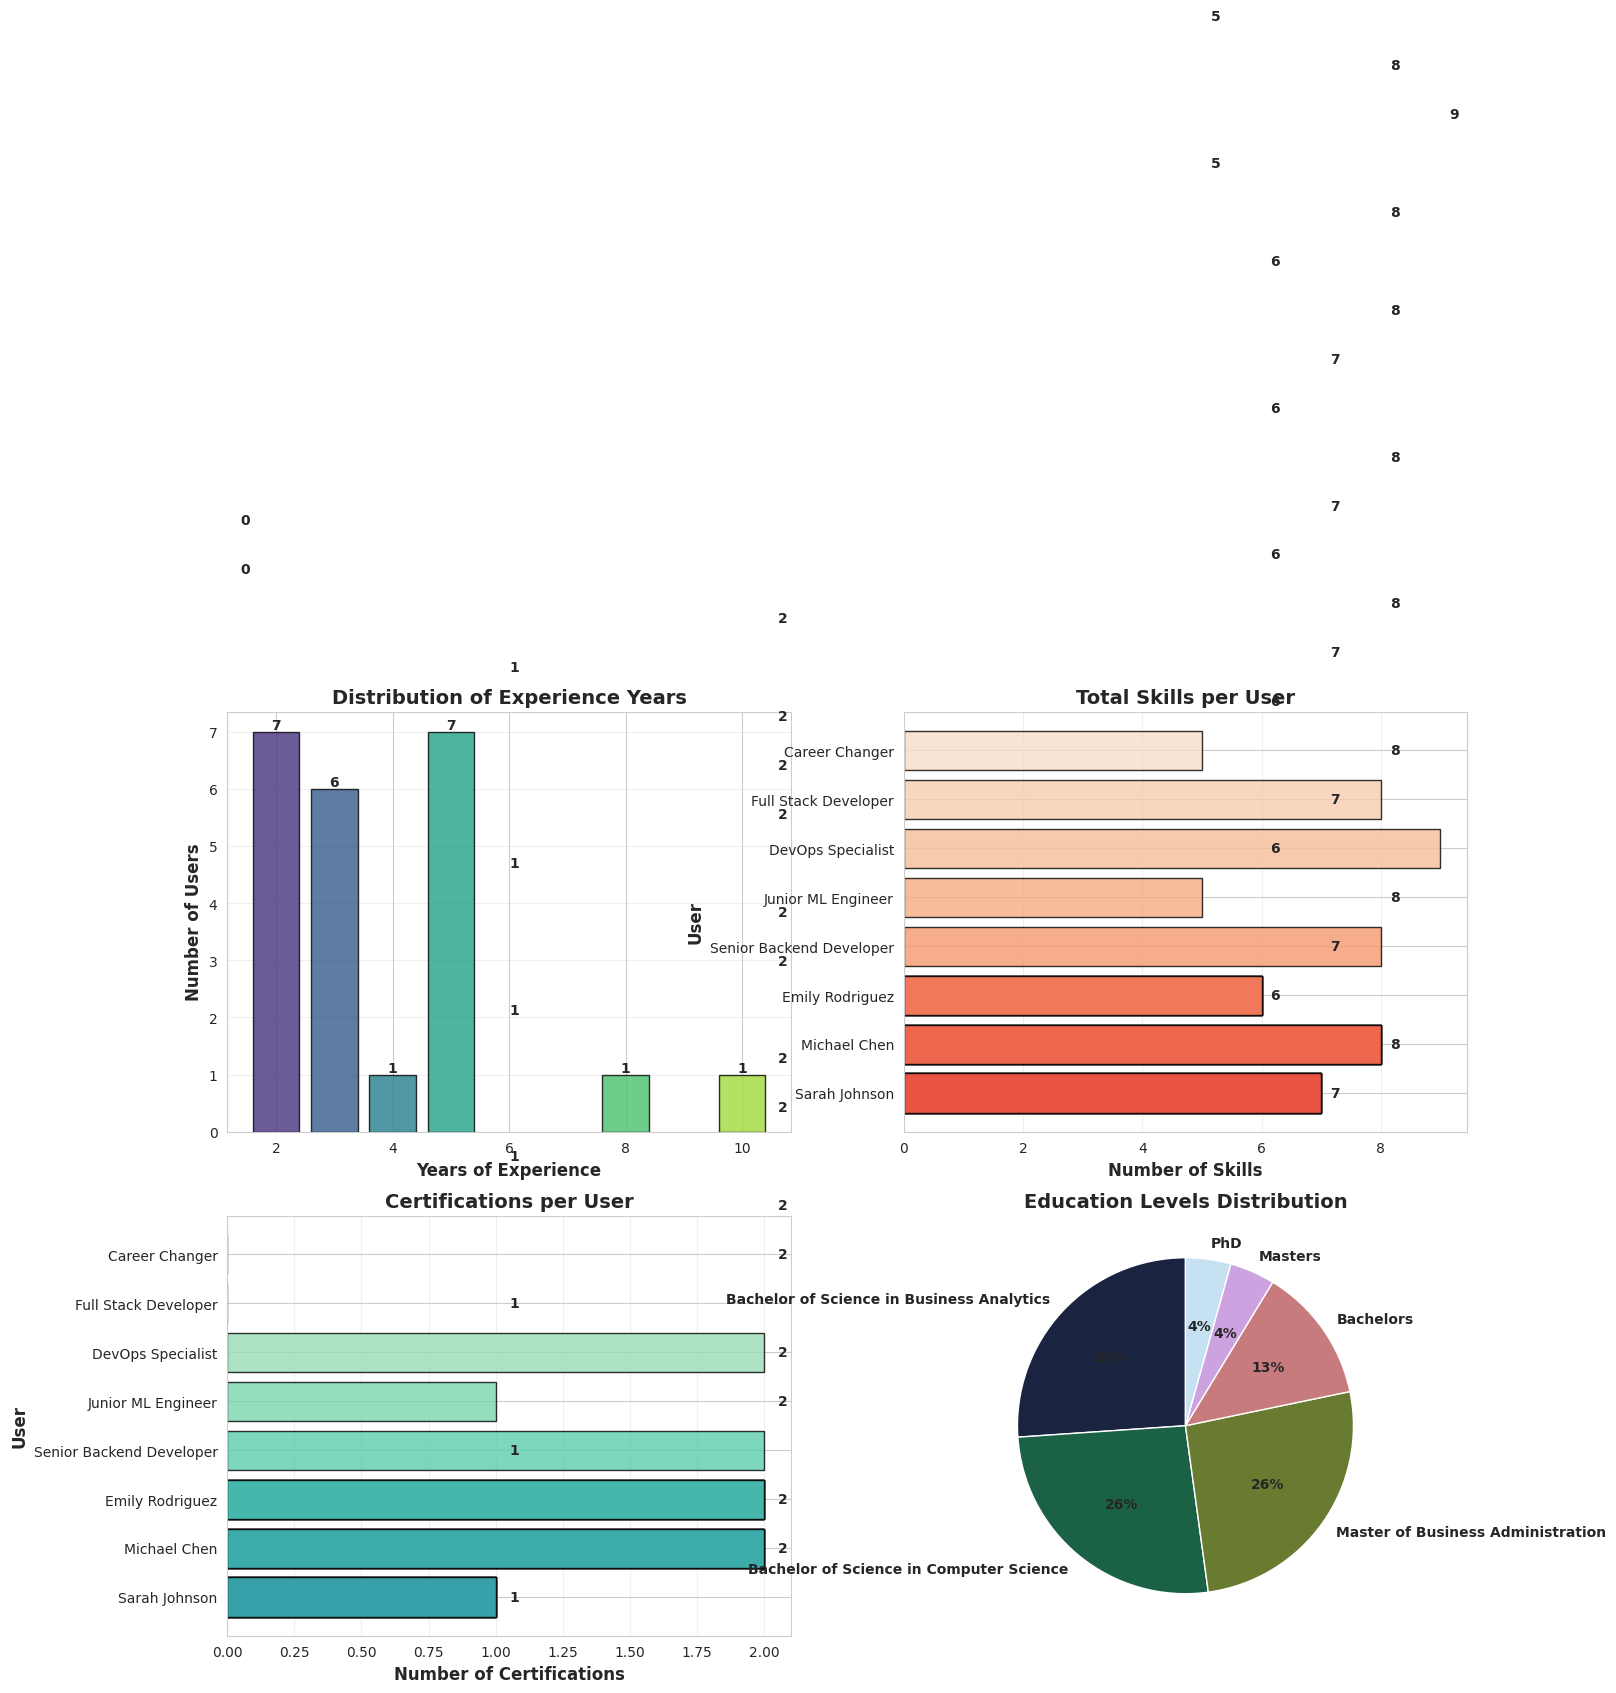


📊 KEY INSIGHTS:
  • Average Experience: 3.9 years
  • Average Skills per User: 7.0
  • Average Certifications: 1.5
  • Most Common Education Level: Bachelor of Science in Business Analytics


In [0]:
# ==============================================================================
# USER DEMOGRAPHICS ANALYSIS
# ==============================================================================

print("\n" + "="*80)
print("USER DEMOGRAPHICS ANALYSIS")
print("="*80)

# Create a demographics summary
user_profiles_df['num_skills'] = user_profiles_df['current_skills'].apply(len)
user_profiles_df['num_certifications'] = user_profiles_df['certifications'].apply(len)

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Experience Years Distribution
ax1 = axes[0, 0]
experience_data = user_profiles_df['experience_years'].value_counts().sort_index()
colors = sns.color_palette('viridis', len(experience_data))
ax1.bar(experience_data.index, experience_data.values, color=colors, edgecolor='black', alpha=0.8)
ax1.set_xlabel('Years of Experience', fontsize=12, fontweight='bold')
ax1.set_ylabel('Number of Users', fontsize=12, fontweight='bold')
ax1.set_title('Distribution of Experience Years', fontsize=14, fontweight='bold')
ax1.grid(axis='y', alpha=0.3)
for i, v in enumerate(experience_data.values):
    ax1.text(experience_data.index[i], v + 0.05, str(v), ha='center', fontweight='bold')

# 2. Number of Skills per User
ax2 = axes[0, 1]
skills_data = user_profiles_df.set_index('name')['num_skills']
colors = sns.color_palette('rocket', len(skills_data))
ax2.barh(skills_data.index, skills_data.values, color=colors, edgecolor='black', alpha=0.8)
ax2.set_xlabel('Number of Skills', fontsize=12, fontweight='bold')
ax2.set_ylabel('User', fontsize=12, fontweight='bold')
ax2.set_title('Total Skills per User', fontsize=14, fontweight='bold')
ax2.grid(axis='x', alpha=0.3)
for i, v in enumerate(skills_data.values):
    ax2.text(v + 0.15, i, str(v), va='center', fontweight='bold')

# 3. Number of Certifications per User
ax3 = axes[1, 0]
cert_data = user_profiles_df.set_index('name')['num_certifications']
colors = sns.color_palette('mako', len(cert_data))
ax3.barh(cert_data.index, cert_data.values, color=colors, edgecolor='black', alpha=0.8)
ax3.set_xlabel('Number of Certifications', fontsize=12, fontweight='bold')
ax3.set_ylabel('User', fontsize=12, fontweight='bold')
ax3.set_title('Certifications per User', fontsize=14, fontweight='bold')
ax3.grid(axis='x', alpha=0.3)
for i, v in enumerate(cert_data.values):
    ax3.text(v + 0.05, i, str(v), va='center', fontweight='bold')

# 4. Education Levels
ax4 = axes[1, 1]
edu_data = user_profiles_df['education'].value_counts()
colors = sns.color_palette('cubehelix', len(edu_data))
wedges, texts, autotexts = ax4.pie(edu_data.values, labels=edu_data.index, autopct='%1.0f%%',
                                     colors=colors, startangle=90, textprops={'fontsize': 10, 'fontweight': 'bold'})
ax4.set_title('Education Levels Distribution', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('/Workspace/Users/deepikashrestha@sandiego.edu/user_demographics_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n KEY INSIGHTS:")
print(f"  • Average Experience: {user_profiles_df['experience_years'].mean():.1f} years")
print(f"  • Average Skills per User: {user_profiles_df['num_skills'].mean():.1f}")
print(f"  • Average Certifications: {user_profiles_df['num_certifications'].mean():.1f}")
print(f"  • Most Common Education Level: {user_profiles_df['education'].mode()[0]}")


CAREER PROGRESSION ANALYSIS

📋 CAREER TRANSITIONS:


name,current_role,desired_role,experience_years,role_change
Sarah Johnson,Junior Data Analyst,Data Scientist,2,true
Michael Chen,Full Stack Developer,Senior Software Engineer,5,true
Emily Rodriguez,Project Coordinator,Project Manager,3,true
Sarah Johnson,Junior Data Analyst,Data Scientist,2,true
Michael Chen,Full Stack Developer,Senior Software Engineer,5,true
Emily Rodriguez,Project Coordinator,Project Manager,3,true
Sarah Johnson,Junior Data Analyst,Data Scientist,2,true
Michael Chen,Full Stack Developer,Senior Software Engineer,5,true
Emily Rodriguez,Project Coordinator,Project Manager,3,true
Sarah Johnson,Junior Data Analyst,Data Scientist,2,true


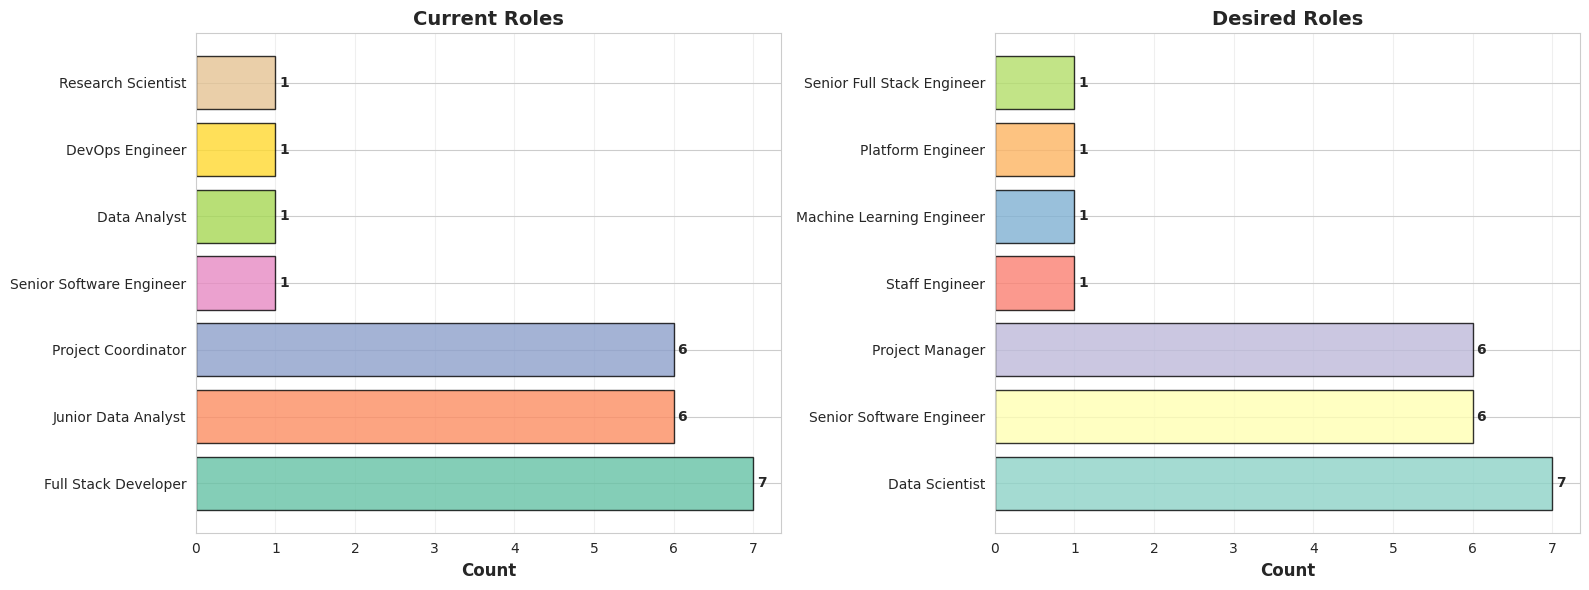


 INSIGHTS:
  • 23/23 users seeking role transitions
  • Average experience for career changers: 3.9 years


In [0]:
# ==============================================================================
# CAREER PROGRESSION PATTERNS
# ==============================================================================

print("\n" + "="*80)
print("CAREER PROGRESSION ANALYSIS")
print("="*80)

# Current Role vs Desired Role Table
career_transition = user_profiles_df[['name', 'current_role', 'desired_role', 'experience_years']].copy()
career_transition['role_change'] = career_transition['current_role'] != career_transition['desired_role']

print("\n CAREER TRANSITIONS:")
print("="*80)
display(career_transition)

# Visualize career transitions
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Left: Current Roles
ax1 = axes[0]
current_roles = user_profiles_df['current_role'].value_counts()
colors = sns.color_palette('Set2', len(current_roles))
y_pos = np.arange(len(current_roles))
ax1.barh(y_pos, current_roles.values, color=colors, edgecolor='black', alpha=0.8)
ax1.set_yticks(y_pos)
ax1.set_yticklabels(current_roles.index)
ax1.set_xlabel('Count', fontsize=12, fontweight='bold')
ax1.set_title('Current Roles', fontsize=14, fontweight='bold')
ax1.grid(axis='x', alpha=0.3)
for i, v in enumerate(current_roles.values):
    ax1.text(v + 0.05, i, str(v), va='center', fontweight='bold')

# Right: Desired Roles
ax2 = axes[1]
desired_roles = user_profiles_df['desired_role'].value_counts()
colors = sns.color_palette('Set3', len(desired_roles))
y_pos = np.arange(len(desired_roles))
ax2.barh(y_pos, desired_roles.values, color=colors, edgecolor='black', alpha=0.8)
ax2.set_yticks(y_pos)
ax2.set_yticklabels(desired_roles.index)
ax2.set_xlabel('Count', fontsize=12, fontweight='bold')
ax2.set_title('Desired Roles', fontsize=14, fontweight='bold')
ax2.grid(axis='x', alpha=0.3)
for i, v in enumerate(desired_roles.values):
    ax2.text(v + 0.05, i, str(v), va='center', fontweight='bold')

plt.tight_layout()
plt.savefig('/Workspace/Users/deepikashrestha@sandiego.edu/career_transitions.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"\n INSIGHTS:")
print(f"  • {career_transition['role_change'].sum()}/{len(career_transition)} users seeking role transitions")
print(f"  • Average experience for career changers: {career_transition[career_transition['role_change']]['experience_years'].mean():.1f} years")


SKILLS ANALYSIS

✓ Total unique skills: 35
✓ Total skill instances: 161

Top 15 Most Common Skills:


Skill,Frequency
Python,11
SQL,8
Excel,7
Tableau,7
Java,7
JavaScript,7
React,7
Node.js,7
Git,7
REST APIs,7


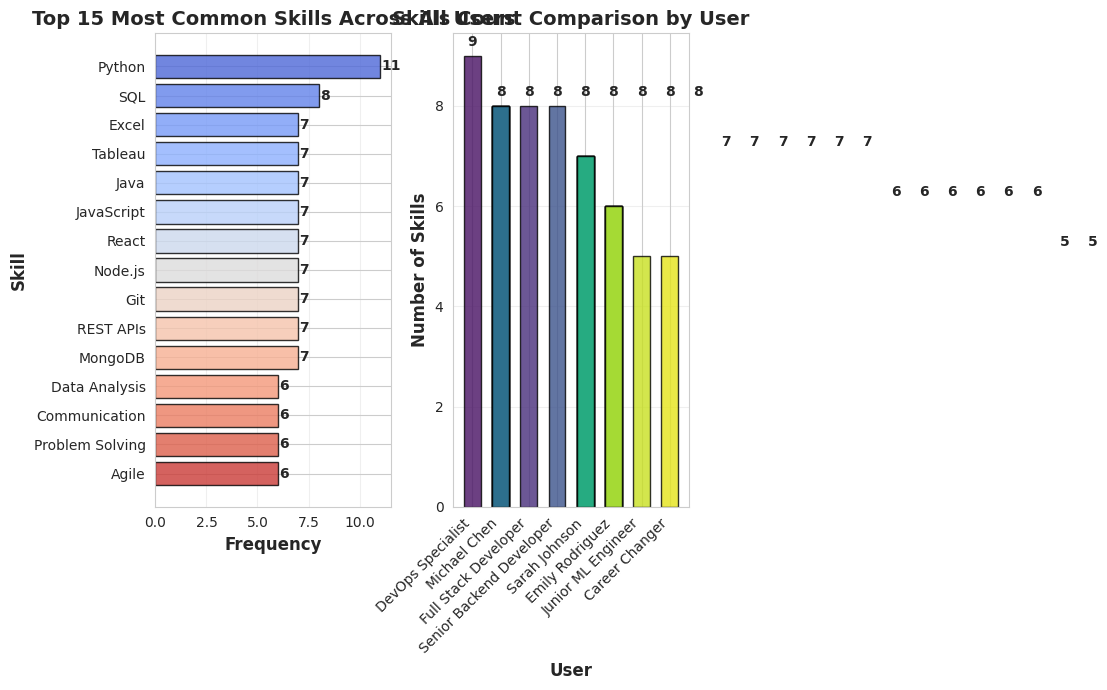


 INSIGHTS:
  • Most common skill: Python (11 users)
  • Average skills per user: 7.0
  • Skills range: 5-9


In [0]:
# ==============================================================================
# SKILLS ANALYSIS
# ==============================================================================

print("\n" + "="*80)
print("SKILLS ANALYSIS")
print("="*80)

# Flatten all skills across users
all_skills = []
for skills_list in user_profiles_df['current_skills']:
    all_skills.extend(skills_list)

# Count skill frequencies
skill_counts = Counter(all_skills)
most_common_skills = pd.DataFrame(skill_counts.most_common(15), columns=['Skill', 'Frequency'])

print(f"\n Total unique skills: {len(skill_counts)}")
print(f" Total skill instances: {len(all_skills)}")
print(f"\nTop 15 Most Common Skills:")
print("="*80)
display(most_common_skills)

# Visualize top skills
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Bar chart of top skills
ax1 = axes[0]
colors = sns.color_palette('coolwarm', len(most_common_skills))
ax1.barh(most_common_skills['Skill'], most_common_skills['Frequency'], 
         color=colors, edgecolor='black', alpha=0.8)
ax1.set_xlabel('Frequency', fontsize=12, fontweight='bold')
ax1.set_ylabel('Skill', fontsize=12, fontweight='bold')
ax1.set_title('Top 15 Most Common Skills Across All Users', fontsize=14, fontweight='bold')
ax1.invert_yaxis()
ax1.grid(axis='x', alpha=0.3)
for i, v in enumerate(most_common_skills['Frequency']):
    ax1.text(v + 0.05, i, str(v), va='center', fontweight='bold')

# Skills per user comparison
ax2 = axes[1]
user_skills_df = user_profiles_df[['name', 'num_skills']].sort_values('num_skills', ascending=False)
colors = sns.color_palette('viridis', len(user_skills_df))
ax2.bar(user_skills_df['name'], user_skills_df['num_skills'], 
        color=colors, edgecolor='black', alpha=0.8, width=0.6)
ax2.set_xlabel('User', fontsize=12, fontweight='bold')
ax2.set_ylabel('Number of Skills', fontsize=12, fontweight='bold')
ax2.set_title('Skills Count Comparison by User', fontsize=14, fontweight='bold')
ax2.grid(axis='y', alpha=0.3)
for i, (name, skills) in enumerate(zip(user_skills_df['name'], user_skills_df['num_skills'])):
    ax2.text(i, skills + 0.2, str(skills), ha='center', fontweight='bold')
plt.setp(ax2.xaxis.get_majorticklabels(), rotation=45, ha='right')

plt.tight_layout()
plt.savefig('/Workspace/Users/deepikashrestha@sandiego.edu/skills_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"\n INSIGHTS:")
print(f"  • Most common skill: {most_common_skills.iloc[0]['Skill']} ({most_common_skills.iloc[0]['Frequency']} users)")
print(f"  • Average skills per user: {user_profiles_df['num_skills'].mean():.1f}")
print(f"  • Skills range: {user_profiles_df['num_skills'].min()}-{user_profiles_df['num_skills'].max()}")

In [0]:
# ==============================================================================
# QUICK CSV EXPORT - Save any DataFrame or analysis results to CSV
# ==============================================================================

import pandas as pd
from datetime import datetime

def save_to_csv(data, filename, output_dir="/Workspace/Users/deepikashrestha@sandiego.edu"):
    """
    Flexible function to save data to CSV.
    
    Args:
        data: Can be a pandas DataFrame, list of dicts, or Spark DataFrame
        filename: Name of the output file (without .csv extension)
        output_dir: Directory to save the file
    
    Returns:
        Path to the saved file
    """
    # Convert to pandas DataFrame if needed
    if hasattr(data, 'toPandas'):  # Spark DataFrame
        df = data.toPandas()
    elif isinstance(data, list):  # List of dictionaries
        df = pd.DataFrame(data)
    elif isinstance(data, pd.DataFrame):  # Already pandas
        df = data
    else:
        raise ValueError("Data must be a pandas DataFrame, Spark DataFrame, or list of dictionaries")
    
    # Add timestamp to filename
    timestamp = datetime.now().strftime('%Y%m%d_%H%M%S')
    filepath = f"{output_dir}/{filename}_{timestamp}.csv"
    
    # Save to CSV
    df.to_csv(filepath, index=False)
    
    print(f" Saved {len(df)} rows to: {filepath}")
    return filepath

print("CSV export function ready!")
print("\n Usage examples:")
print("  save_to_csv(my_dataframe, 'results')")
print("  save_to_csv(all_user_matches['user_001'], 'user_001_matches')")
print("  save_to_csv(spark_df, 'query_results')")


CSV export function ready!

Usage examples:
  save_to_csv(my_dataframe, 'results')
  save_to_csv(all_user_matches['user_001'], 'user_001_matches')
  save_to_csv(spark_df, 'query_results')


In [0]:
# EXAMPLE: Export specific analysis results
# Uncomment the lines you want to use:

# Option 1: Save all matches for a specific user
if 'all_user_matches' in locals():
    # Save Sarah's matches
    save_to_csv(all_user_matches['user_001'], 'sarah_johnson_job_matches')
    
    # Save Michael's matches
    # save_to_csv(all_user_matches['user_002'], 'michael_chen_job_matches')
    
    # Save Emily's matches
    # save_to_csv(all_user_matches['user_003'], 'emily_rodriguez_job_matches')
    
    print("\n Individual user matches exported!")
else:
    print(" Run cells 13-14 first to generate all_user_matches data")

# Option 2: Save user profiles from database
# user_profiles_df = spark.sql("""
#     SELECT * FROM finalproject.careermatch_ai.user_profiles
# """)
# save_to_csv(user_profiles_df, 'user_profiles_export')

# Option 3: Save jobs data
# jobs_df = spark.sql("""
#     SELECT job_id, title, company_name, location, remote_status, salary_category
#     FROM finalproject.careermatch_ai.jobs_vector_ready
#     LIMIT 100
# """)
# save_to_csv(jobs_df, 'jobs_sample')

# Option 4: Save custom query results
# custom_df = spark.sql("""
#     SELECT u.name, u.current_role, COUNT(*) as num_jobs
#     FROM finalproject.careermatch_ai.user_profiles u
#     CROSS JOIN finalproject.careermatch_ai.jobs_vector_ready j
#     GROUP BY u.name, u.current_role
# """)
# save_to_csv(custom_df, 'custom_analysis')

 Saved 100 rows to: /Workspace/Users/deepikashrestha@sandiego.edu/sarah_johnson_job_matches_20260617_174439.csv

 Individual user matches exported!
